In [1]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sb 
import sklearn
import joblib
%matplotlib inline

In [2]:
df = pd.read_csv("./Heart_disease_statlog.csv")
df

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,70,1,3,130,322,0,2,109,0,2.4,1,3,1,1
1,67,0,2,115,564,0,2,160,0,1.6,1,0,3,0
2,57,1,1,124,261,0,0,141,0,0.3,0,0,3,1
3,64,1,3,128,263,0,0,105,1,0.2,1,1,3,0
4,74,0,1,120,269,0,2,121,1,0.2,0,1,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
265,52,1,2,172,199,1,0,162,0,0.5,0,0,3,0
266,44,1,1,120,263,0,0,173,0,0.0,0,0,3,0
267,56,0,1,140,294,0,2,153,0,1.3,1,0,1,0
268,57,1,3,140,192,0,0,148,0,0.4,1,0,2,0


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 270 entries, 0 to 269
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       270 non-null    int64  
 1   sex       270 non-null    int64  
 2   cp        270 non-null    int64  
 3   trestbps  270 non-null    int64  
 4   chol      270 non-null    int64  
 5   fbs       270 non-null    int64  
 6   restecg   270 non-null    int64  
 7   thalach   270 non-null    int64  
 8   exang     270 non-null    int64  
 9   oldpeak   270 non-null    float64
 10  slope     270 non-null    int64  
 11  ca        270 non-null    int64  
 12  thal      270 non-null    int64  
 13  target    270 non-null    int64  
dtypes: float64(1), int64(13)
memory usage: 29.7 KB


In [4]:
df.describe()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,270.000000,270.000000,270.000000,270.000000,270.000000,270.000000,270.000000,270.000000,270.000000,270.00000,270.000000,270.000000,270.000000,270.000000
mean,54.433333,0.677778,2.174074,131.344444,249.659259,0.148148,1.022222,149.677778,0.329630,1.05000,0.585185,0.670370,1.822222,0.444444
std,9.109067,0.468195,0.950090,17.861608,51.686237,0.355906,0.997891,23.165717,0.470952,1.14521,0.614390,0.943896,0.959140,0.497827
min,29.000000,0.000000,0.000000,94.000000,126.000000,0.000000,0.000000,71.000000,0.000000,0.00000,0.000000,0.000000,1.000000,0.000000
25%,48.000000,0.000000,2.000000,120.000000,213.000000,0.000000,0.000000,133.000000,0.000000,0.00000,0.000000,0.000000,1.000000,0.000000
50%,55.000000,1.000000,2.000000,130.000000,245.000000,0.000000,2.000000,153.500000,0.000000,0.80000,1.000000,0.000000,1.000000,0.000000
75%,61.000000,1.000000,3.000000,140.000000,280.000000,0.000000,2.000000,166.000000,1.000000,1.60000,1.000000,1.000000,3.000000,1.000000
max,77.000000,1.000000,3.000000,200.000000,564.000000,1.000000,2.000000,202.000000,1.000000,6.20000,2.000000,3.000000,3.000000,1.000000


<AxesSubplot:>

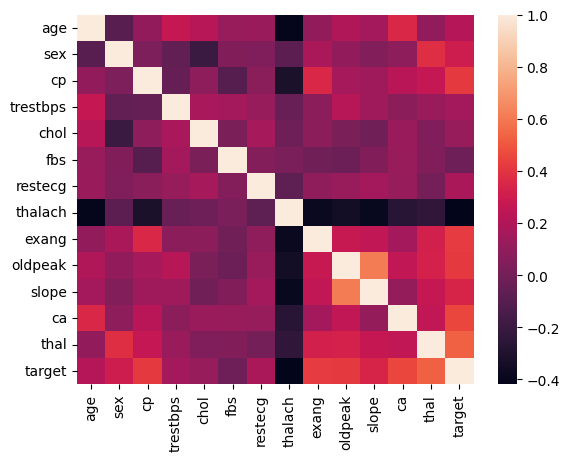

In [5]:
corr = df.corr()
sb.heatmap(corr)

In [6]:
corr

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
age,1.000000,-0.094401,0.096920,0.273053,0.220056,0.123458,0.128171,-0.402215,0.098297,0.194234,0.159774,0.356081,0.099055,0.212322
sex,-0.094401,1.000000,0.034636,-0.062693,-0.201647,0.042140,0.039253,-0.076101,0.180022,0.097412,0.050545,0.086830,0.376936,0.297721
cp,0.096920,0.034636,1.000000,-0.043196,0.090465,-0.098537,0.074325,-0.317682,0.353160,0.167244,0.136900,0.225890,0.266614,0.417436
trestbps,0.273053,-0.062693,-0.043196,1.000000,0.173019,0.155681,0.116157,-0.039136,0.082793,0.222800,0.142472,0.085697,0.127273,0.155383
chol,0.220056,-0.201647,0.090465,0.173019,1.000000,0.025186,0.167652,-0.018739,0.078243,0.027709,-0.005755,0.126541,0.040317,0.118021
fbs,0.123458,0.042140,-0.098537,0.155681,0.025186,1.000000,0.053499,0.022494,-0.004107,-0.025538,0.044076,0.123774,0.044770,-0.016319
restecg,0.128171,0.039253,0.074325,0.116157,0.167652,0.053499,1.000000,-0.074628,0.095098,0.120034,0.160614,0.114368,0.004143,0.182091
thalach,-0.402215,-0.076101,-0.317682,-0.039136,-0.018739,0.022494,-0.074628,1.000000,-0.380719,-0.349045,-0.386847,-0.265333,-0.241003,-0.418514
exang,0.098297,0.180022,0.353160,0.082793,0.078243,-0.004107,0.095098,-0.380719,1.000000,0.274672,0.255908,0.153347,0.319499,0.419303
oldpeak,0.194234,0.097412,0.167244,0.222800,0.027709,-0.025538,0.120034,-0.349045,0.274672,1.000000,0.609712,0.255005,0.325240,0.417967


In [7]:
def routlier(cols):
    df_clean = df.copy()[["trestbps", "chol", "thalach"]]
    
    for col in cols:
        Q1 = df_clean[col].quantile(0.25)
        Q3 = df_clean[col].quantile(0.75)
        IQR = Q3 - Q1

        lower = Q1 - 1.5 * IQR
        upper = Q3 + 1.5 * IQR

        df_clean = df_clean[
            (df_clean[col] >= lower) &
            (df_clean[col] <= upper)
        ]
    return df_clean

df[["trestbps", "chol", "thalach"]] = routlier(["trestbps", "chol", "thalach"])
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 270 entries, 0 to 269
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       270 non-null    int64  
 1   sex       270 non-null    int64  
 2   cp        270 non-null    int64  
 3   trestbps  255 non-null    float64
 4   chol      255 non-null    float64
 5   fbs       270 non-null    int64  
 6   restecg   270 non-null    int64  
 7   thalach   255 non-null    float64
 8   exang     270 non-null    int64  
 9   oldpeak   270 non-null    float64
 10  slope     270 non-null    int64  
 11  ca        270 non-null    int64  
 12  thal      270 non-null    int64  
 13  target    270 non-null    int64  
dtypes: float64(4), int64(10)
memory usage: 29.7 KB


In [8]:
df.dropna(inplace=True)
df

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,70,1,3,130.0,322.0,0,2,109.0,0,2.4,1,3,1,1
2,57,1,1,124.0,261.0,0,0,141.0,0,0.3,0,0,3,1
3,64,1,3,128.0,263.0,0,0,105.0,1,0.2,1,1,3,0
4,74,0,1,120.0,269.0,0,2,121.0,1,0.2,0,1,1,0
5,65,1,3,120.0,177.0,0,0,140.0,0,0.4,0,0,3,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
264,48,1,1,110.0,229.0,0,0,168.0,0,1.0,2,0,3,1
266,44,1,1,120.0,263.0,0,0,173.0,0,0.0,0,0,3,0
267,56,0,1,140.0,294.0,0,2,153.0,0,1.3,1,0,1,0
268,57,1,3,140.0,192.0,0,0,148.0,0,0.4,1,0,2,0


In [9]:
x = df.iloc[:, :-1].values
y = df.iloc[:, -1].values

In [10]:
from sklearn.model_selection import train_test_split 

train_x, test_x, train_y, test_y = train_test_split(x, y, test_size=0.2, random_state=0)

In [11]:
from sklearn.preprocessing import StandardScaler
sc = StandardScaler()
train_x = sc.fit_transform(train_x)
test_x = sc.transform(test_x)

joblib.dump(sc,"sc.pkl")

['sc.pkl']

In [12]:
from sklearn.linear_model import LogisticRegression 

model = LogisticRegression()
model.fit(train_x, train_y)

LogisticRegression()

In [13]:
y_pre = model.predict(test_x)
y_pre_train = model.predict(train_x)

In [14]:
from sklearn.metrics import accuracy_score, mean_absolute_error, mean_squared_error

print("test x, y: ",format(model.score(test_x, test_y)))
print("test y, y_pre: ",format(accuracy_score(test_y, y_pre)))
print("test y, y_pre: ",format(accuracy_score(train_y, y_pre_train)))

test x, y:  0.7450980392156863
test y, y_pre:  0.7450980392156863
test y, y_pre:  0.8774509803921569


In [15]:
from sklearn.model_selection import cross_val_score

modelc = cross_val_score(
    estimator= model, 
    X= train_x, 
    y= train_y, 
    cv = 10)
print(modelc.mean()*100)
print(modelc.std()*100)

83.30952380952381
9.415123887826928


In [16]:
from sklearn.model_selection import GridSearchCV

pars = {
    'C': [0.01, 0.1, 1, 10, 100]
}

grid_model = GridSearchCV(
    model, 
    pars,
    cv = 10,
    scoring="accuracy"
)
grid_model.fit(train_x, train_y)

GridSearchCV(cv=10, estimator=LogisticRegression(),
             param_grid={'C': [0.01, 0.1, 1, 10, 100]}, scoring='accuracy')

In [17]:
grid_model.best_score_

0.847857142857143

In [18]:
best_model = grid_model.best_estimator_
joblib.dump(best_model,"best_model.pkl")
best_model

LogisticRegression(C=0.1)

In [19]:
y_pre = best_model.predict(test_x)
y_pre_train = best_model.predict(train_x)

print("For score Test(test-x test-y): ",format(best_model.score(test_x, test_y)))
print("For Test(test-y, y-predict-test): ",format(accuracy_score(test_y, y_pre)))
print("For Train(train-y y-predict-train): ",format(accuracy_score(train_y, y_pre_train)))

For score Test(test-x test-y):  0.7843137254901961
For Test(test-y, y-predict-test):  0.7843137254901961
For Train(train-y y-predict-train):  0.8774509803921569


<h1>Predict</h1>

In [20]:
model = joblib.load("best_model.pkl")
scaler = joblib.load("sc.pkl")

user_data = [[70, 1, 0, 170, 150, 1,
        2,2002, 1, 2.4,1, 1,
        1]]

user_data = scaler.transform(user_data)

result = model.predict(user_data)
print(result)

[0]
